In [1]:
import pandas as pd
fruites = pd.DataFrame([[30,20]], columns=['Pomes', 'Maduixes'])
fruites

,Pomes,Maduixes
0,30,20


In [2]:
fruites_compradors=pd.DataFrame([[30,20],[28,14]],index=['Miquel','Julia'],columns=['Pomes', 'Maduixes'])
fruites_compradors

,Pomes,Maduixes
Miquel,30,20
Julia,28,14


In [3]:
fruites_compradors_2 = pd.DataFrame({'Pomes':[30,28],'Maduixes':[20,14]}, index=['Miquel','Julia'])
fruites_compradors_2

,Pomes,Maduixes
Miquel,30,20
Julia,28,14


In [4]:
print(fruites_compradors_2 is fruites_compradors)

False


In [5]:
fruites_compradors = fruites_compradors_2
print(fruites_compradors_2 is fruites_compradors)

True


In [6]:
fruites_compradors['Pomes'][0] =15
fruites_compradors

/tmp/ipykernel_46969/954171548.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  fruites_compradors['Pomes'][0] =15
/tmp/ipykernel_46969/954171548.py:1: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a futur

,Pomes,Maduixes
Miquel,15,20
Julia,28,14


# Indexa, seleccionar y filtrar

In [7]:
data_base = pd.read_csv('insurance.csv')
data_base.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
pd.set_option("display.max_rows", 5)
data_base

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
...,...,...,...,...,...,...,...
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [9]:
data_base['region']

0       southwest
1       southeast
          ...    
1336    southwest
1337    northwest
Name: region, Length: 1338, dtype: object

In [10]:
data_base['bmi'].max()

np.float64(53.13)

In [11]:
bmi_30 = data_base['bmi'][0:30]
bmi_30

0     27.900
1     33.770
       ...  
28    17.385
29    36.300
Name: bmi, Length: 30, dtype: float64

In [12]:
bmi_30.max()

np.float64(42.13)

In [13]:
data_base_2 = data_base.iloc[0:10,0:2]

In [14]:
data_base_2

,age,sex
0,19,female
1,18,male
...,...,...
8,37,male
9,60,female


In [15]:
data_base_3 = data_base.iloc[[0,5,6],[0,4]]
data_base_3

,age,smoker
0,19,yes
5,31,no
6,46,no


In [16]:
data_base_4 = data_base.loc[0:8,['children','age']]
data_base_4

,children,age
0,0,19
1,1,18
...,...,...
7,3,37
8,2,37


In [17]:
data_base_southwest = data_base.loc[data_base.region == 'southwest']
data_base_southwest.iloc[0:7,0:2]

,age,sex
0,19,female
12,23,male
...,...,...
21,30,female
29,31,male


In [18]:
data_base.loc[(data_base.bmi >= 35) & (data_base.bmi <= 45)].describe()

,age,bmi,children,charges
count,296.000000,296.000000,296.000000,296.000000
mean,41.679054,38.301976,1.027027,16913.681515
...,...,...,...,...
75%,54.000000,39.840000,2.000000,26781.395215
max,64.000000,44.880000,5.000000,58571.074480


In [20]:
approved = []
for bmi in data_base['bmi']:
 if bmi < 45:
     approved.append(True)
 else:
     approved.append(False)
data_base['approved'] = approved

pd.set_option("display.max_rows", 20)
data_base.head(20)

,age,sex,bmi,children,smoker,region,charges,approved
0,19,female,27.900,0,yes,southwest,16884.92400,True
1,18,male,33.770,1,no,southeast,1725.55230,True
2,28,male,33.000,3,no,southeast,4449.46200,True
3,33,male,22.705,0,no,northwest,21984.47061,True
4,32,male,28.880,0,no,northwest,3866.85520,True
5,31,female,25.740,0,no,southeast,3756.62160,True
6,46,female,33.440,1,no,southeast,8240.58960,True
7,37,female,27.740,3,no,northwest,7281.50560,True
8,37,male,29.830,2,no,northeast,6406.41070,True
9,60,female,25.840,0,no,northwest,28923.13692,True


# Ordenar y Agrupar datos no disponibles

In [21]:
data_frame = pd.read_csv('insurance.csv')
data_frame.groupby('region').size()

region
northeast    324
northwest    325
southeast    364
southwest    325
dtype: int64

In [22]:
data_frame.groupby('region')['bmi'].max()

region
northeast    48.07
northwest    42.94
southeast    53.13
southwest    47.60
Name: bmi, dtype: float64

In [23]:
data_frame.groupby('region')['bmi'].mean()

region
northeast    29.173503
northwest    29.199785
southeast    33.355989
southwest    30.596615
Name: bmi, dtype: float64

In [24]:
sorted(data_frame.groupby('region')['bmi'].mean())

[29.173503086419753, 29.199784615384615, 30.596615384615383, 33.35598901098901]

In [25]:
data_frame.groupby(['region', 'smoker'])['charges'].mean()

region     smoker
northeast  no         9165.531672
           yes       29673.536473
northwest  no         8556.463715
           yes       30192.003182
southeast  no         8032.216309
           yes       34844.996824
southwest  no         8019.284513
           yes       32269.063494
Name: charges, dtype: float64

In [26]:
data_frame.groupby(['region', 'sex'])['charges'].mean()

region     sex   
northeast  female    12953.203151
           male      13854.005374
northwest  female    12479.870397
           male      12354.119575
southeast  female    13499.669243
           male      15879.617173
southwest  female    11274.411264
           male      13412.883576
Name: charges, dtype: float64

<Axes: xlabel='region'>

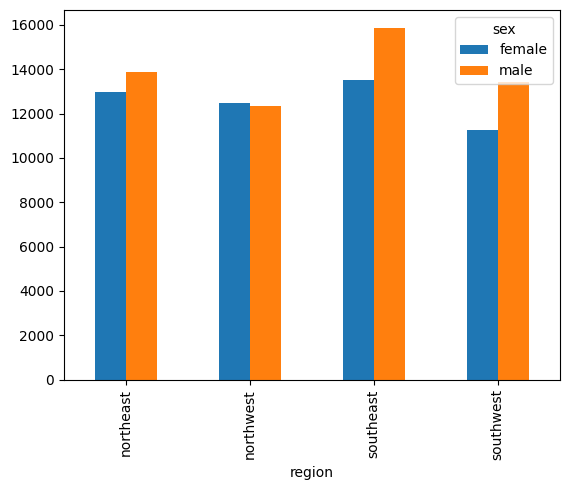

In [27]:
group = data_frame.groupby(['region', 'sex'])['charges'].mean()
group.unstack(fill_value=0).plot.bar()

In [28]:
data_frame.sort_values(['age','bmi'])

,age,sex,bmi,children,smoker,region,charges
172,18,male,15.960,0,no,northeast,1694.79640
250,18,male,17.290,2,yes,northeast,12829.45510
359,18,female,20.790,0,no,southeast,1607.51010
1212,18,male,21.470,0,no,northeast,1702.45530
1033,18,male,21.565,0,yes,northeast,13747.87235
...,...,...,...,...,...,...,...
603,64,female,39.050,3,no,southeast,16085.12750
418,64,male,39.160,1,no,southeast,14418.28040
199,64,female,39.330,0,no,northeast,14901.51670
768,64,female,39.700,0,no,southwest,14319.03100


In [29]:
data_frame.sort_values(['age','bmi']).head(12)

,age,sex,bmi,children,smoker,region,charges
172,18,male,15.960,0,no,northeast,1694.79640
250,18,male,17.290,2,yes,northeast,12829.45510
359,18,female,20.790,0,no,southeast,1607.51010
1212,18,male,21.470,0,no,northeast,1702.45530
1033,18,male,21.565,0,yes,northeast,13747.87235
1282,18,female,21.660,0,yes,northeast,14283.45940
1080,18,male,21.780,2,no,southeast,11884.04858
295,18,male,22.990,0,no,northeast,1704.56810
1041,18,male,23.085,0,no,northeast,1704.70015
940,18,male,23.210,0,no,southeast,1121.87390


In [30]:
data_frame.sort_values(['age','bmi'], ascending=[False, False]).head(12)

,age,sex,bmi,children,smoker,region,charges
534,64,male,40.480,0,no,southeast,13831.11520
768,64,female,39.700,0,no,southwest,14319.03100
199,64,female,39.330,0,no,northeast,14901.51670
418,64,male,39.160,1,no,southeast,14418.28040
603,64,female,39.050,3,no,southeast,16085.12750
635,64,male,38.190,0,no,northeast,14410.93210
752,64,male,37.905,0,no,northwest,14210.53595
1241,64,male,36.960,2,yes,southeast,49577.66240
801,64,female,35.970,0,no,southeast,14313.84630
335,64,male,34.500,0,no,southwest,13822.80300
